# Baseline Model: Linear Regression

This notebook implements the project baseline model for **national electricity demand forecasting** using:
- lagged demand features (autoregressive signal)
- socio-economic features (`gdp`, `population`, `gdp_per_capita`)

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 2003-2019, Test = 2020-2023  
**Metrics:** RMSE and MAE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load dataset
DATA_PATH = 'df_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: df_clean.csv
Shape: 6994 rows x 18 columns
Countries: 181
Year range: 1985-2024


,country,year,population,iso_code,gdp,biofuel_electricity,coal_electricity,electricity_demand,electricity_generation,fossil_electricity,gas_electricity,greenhouse_gas_emissions,hydro_electricity,nuclear_electricity,oil_electricity,renewables_electricity,solar_electricity,wind_electricity
0,American Samoa,1985,39128.0,ASM,6.040371e+08,0.0,0.0,0.078,0.078,0.078,NaN,0.018,0.0,0.0,NaN,0.0,0.0,0.0
1,American Samoa,1986,40588.0,ASM,6.894330e+08,0.0,0.0,0.084,0.084,0.084,NaN,0.024,0.0,0.0,NaN,0.0,0.0,0.0
2,American Samoa,1987,42095.0,ASM,7.549983e+08,0.0,0.0,0.090,0.090,0.090,NaN,0.030,0.0,0.0,NaN,0.0,0.0,0.0
3,American Samoa,1988,43634.0,ASM,7.891841e+08,0.0,0.0,0.096,0.096,0.096,NaN,0.036,0.0,0.0,NaN,0.0,0.0,0.0
4,American Samoa,1989,45207.0,ASM,8.419489e+08,0.0,0.0,0.102,0.102,0.102,NaN,0.042,0.0,0.0,NaN,0.0,0.0,0.0


In [3]:
# Feature engineering
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

# Lagged year-over-year change (no leakage): (t-1) - (t-2)
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)

# Exogenous interaction
df['gdp_per_capita'] = df['gdp'] / df['population']

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
df_model[['country', 'year'] + FEATURE_COLS + [TARGET]].head()

Usable rows after lag features: 6451


,country,year,demand_lag1,demand_lag2,demand_lag3,demand_yoy_change,gdp,population,gdp_per_capita,electricity_demand
3,American Samoa,1988,0.090,0.084,0.078,0.006,7.891841e+08,43634.0,18086.449396,0.096
4,American Samoa,1989,0.096,0.090,0.084,0.006,8.419489e+08,45207.0,18624.303326,0.102
5,American Samoa,1990,0.102,0.096,0.090,0.006,8.735035e+08,46659.0,18721.008140,0.108
6,American Samoa,1991,0.108,0.102,0.096,0.006,9.136560e+08,47903.0,19073.043107,0.114
7,American Samoa,1992,0.114,0.108,0.102,0.006,9.605524e+08,49054.0,19581.530228,0.120


In [4]:
# Temporal train/test split
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows: {len(test)}')
print(f'Features: {FEATURE_COLS}')

Train rows: 5623
Test rows: 828
Features: ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [5]:
# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [6]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 12.211 TWh | Train MAE: 2.437 TWh
Test RMSE : 23.986 TWh | Test MAE : 5.263 TWh


In [7]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
29,China,5,256.924,222.675
173,United States,5,132.332,130.543
72,India,5,69.984,55.558
133,Russia,5,35.483,29.834
78,Japan,5,32.488,27.542
...,...,...,...,...
151,Somalia,4,0.137,0.133
13,Benin,4,0.101,0.096
154,South Sudan,5,0.098,0.091
134,Rwanda,4,0.058,0.048


In [8]:
# Coefficients (interpretability)
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: -0.4513


,feature,coefficient
0,demand_lag1,9.062015e-01
3,demand_yoy_change,5.497474e-01
1,demand_lag2,3.564534e-01
2,demand_lag3,-2.512056e-01
6,gdp_per_capita,-2.449995e-06
5,population,3.880738e-08
4,gdp,-2.400136e-12


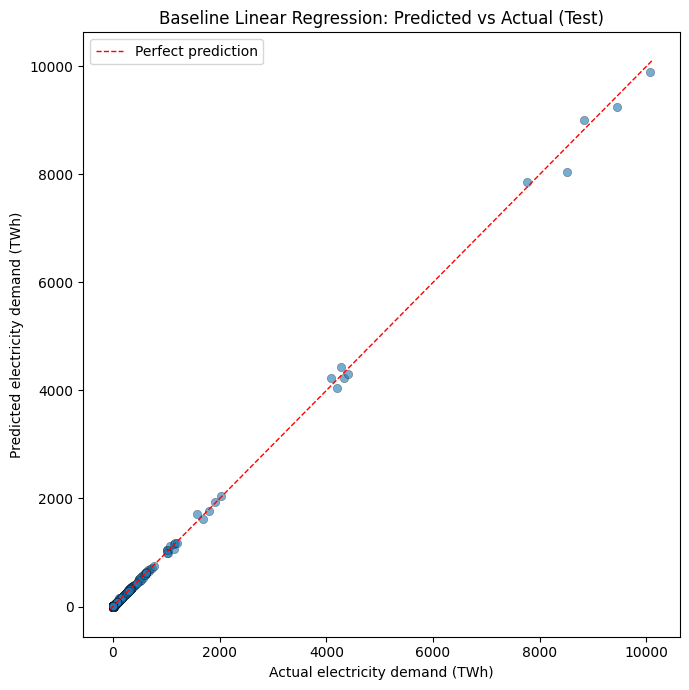

In [9]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

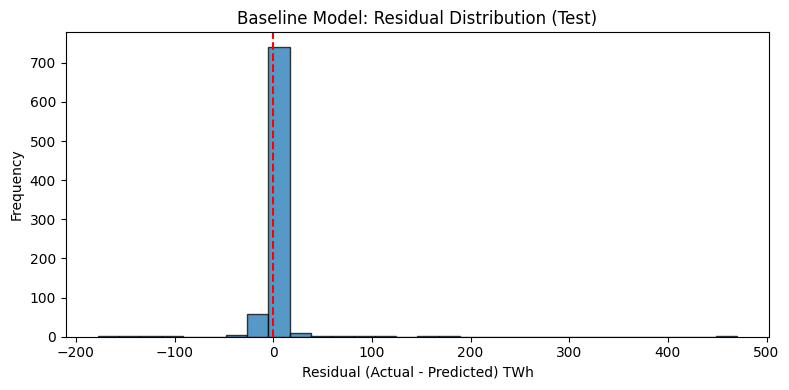

In [10]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

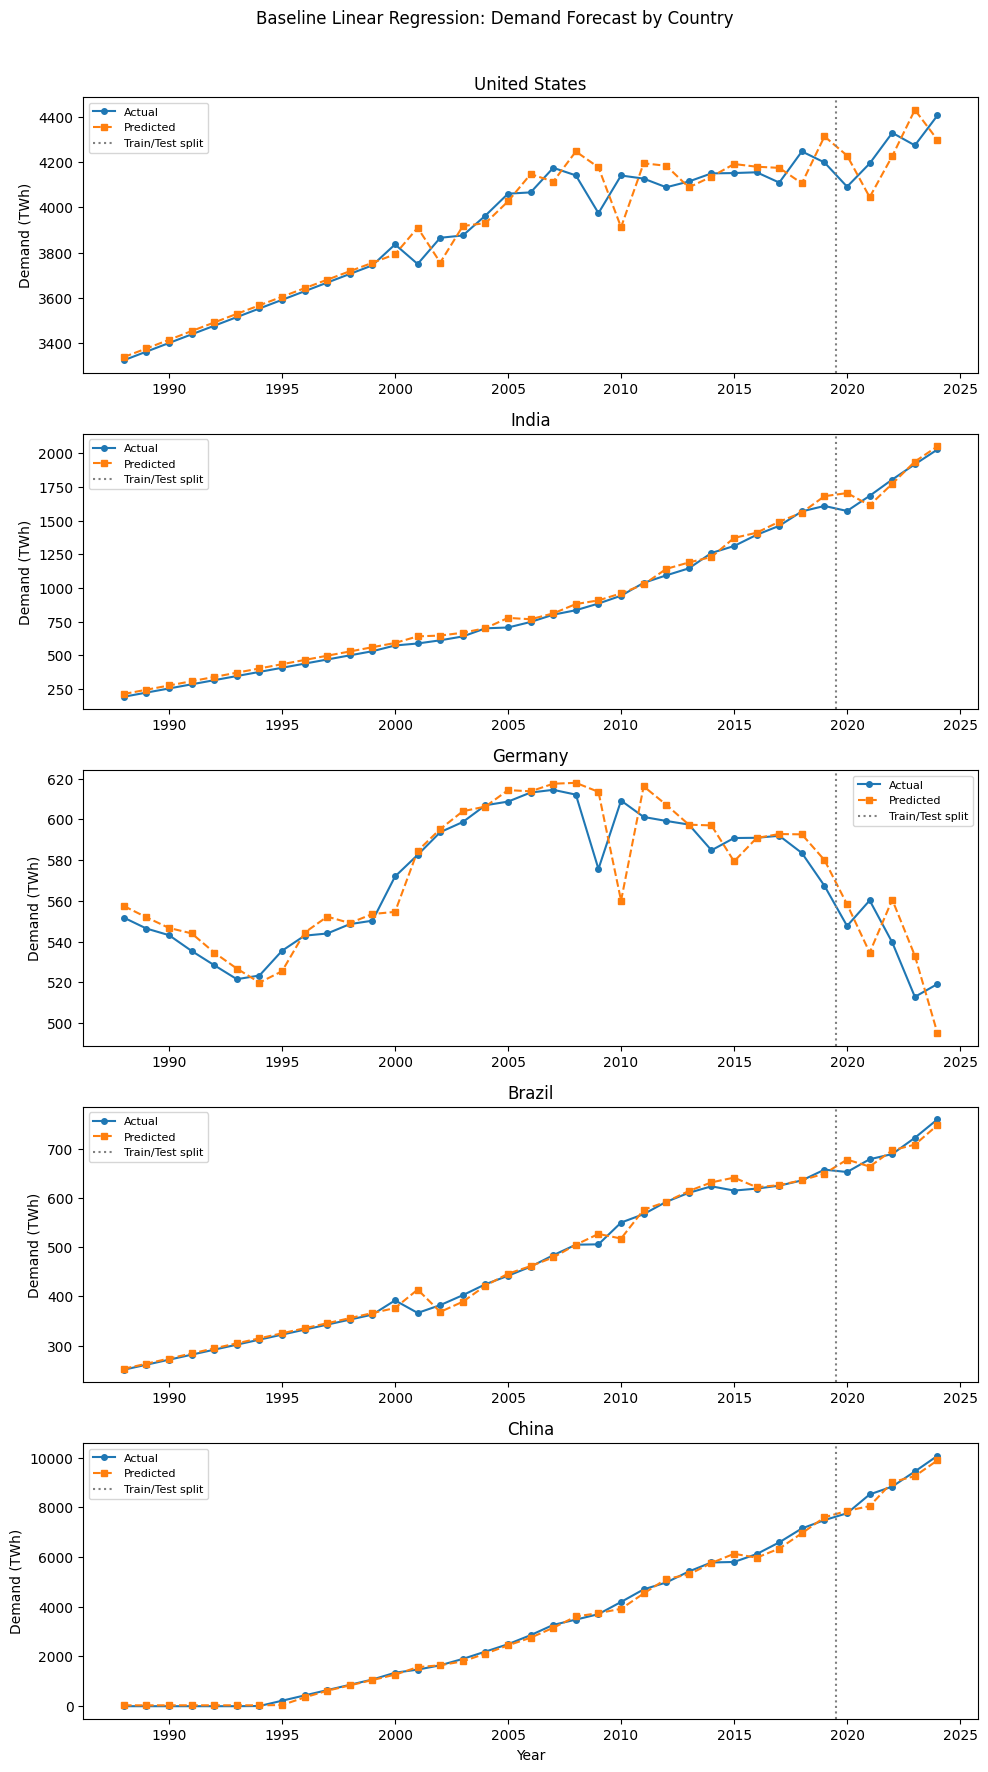

In [11]:
# Plot 3: Country-level overlays
preferred_countries = ['United States', 'India', 'Germany', 'Brazil', 'China']
available_countries = df_model['country'].unique()
sample_countries = [c for c in preferred_countries if c in available_countries]

# Fall back to top-4 countries by test RMSE if none of the defaults are present
if not sample_countries:
    sample_countries = country_metrics['country'].head(4).tolist()

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    cdf['predicted'] = model.predict(cdf[FEATURE_COLS])

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Baseline Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()


In [12]:
# Table of actual vs predicted for for all countries in test set
results_df = test[['country', 'year', TARGET]].copy()
results_df['predicted'] = y_pred_test
results_df.head(30)

,country,year,electricity_demand,predicted
35,American Samoa,2020,0.170000,-0.384165
36,American Samoa,2021,0.170000,-0.373958
37,American Samoa,2022,0.180000,-0.378072
38,American Samoa,2023,0.170000,-0.365614
74,Antigua and Barbuda,2020,0.350000,-0.106360
75,Antigua and Barbuda,2021,0.350000,-0.124951
76,Antigua and Barbuda,2022,0.360000,-0.123472
77,Antigua and Barbuda,2023,0.360000,-0.106234
113,Argentina,2020,149.350006,148.783960
114,Argentina,2021,155.649994,148.449431


## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It should be compared directly against SARIMAX (same split and metrics).
- If SARIMAX cannot beat this baseline on Test RMSE/MAE, revisit feature engineering or SARIMAX specification.

Forecast ready for: ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']
Damping factor: 0.8 | Floor percentile: 10th


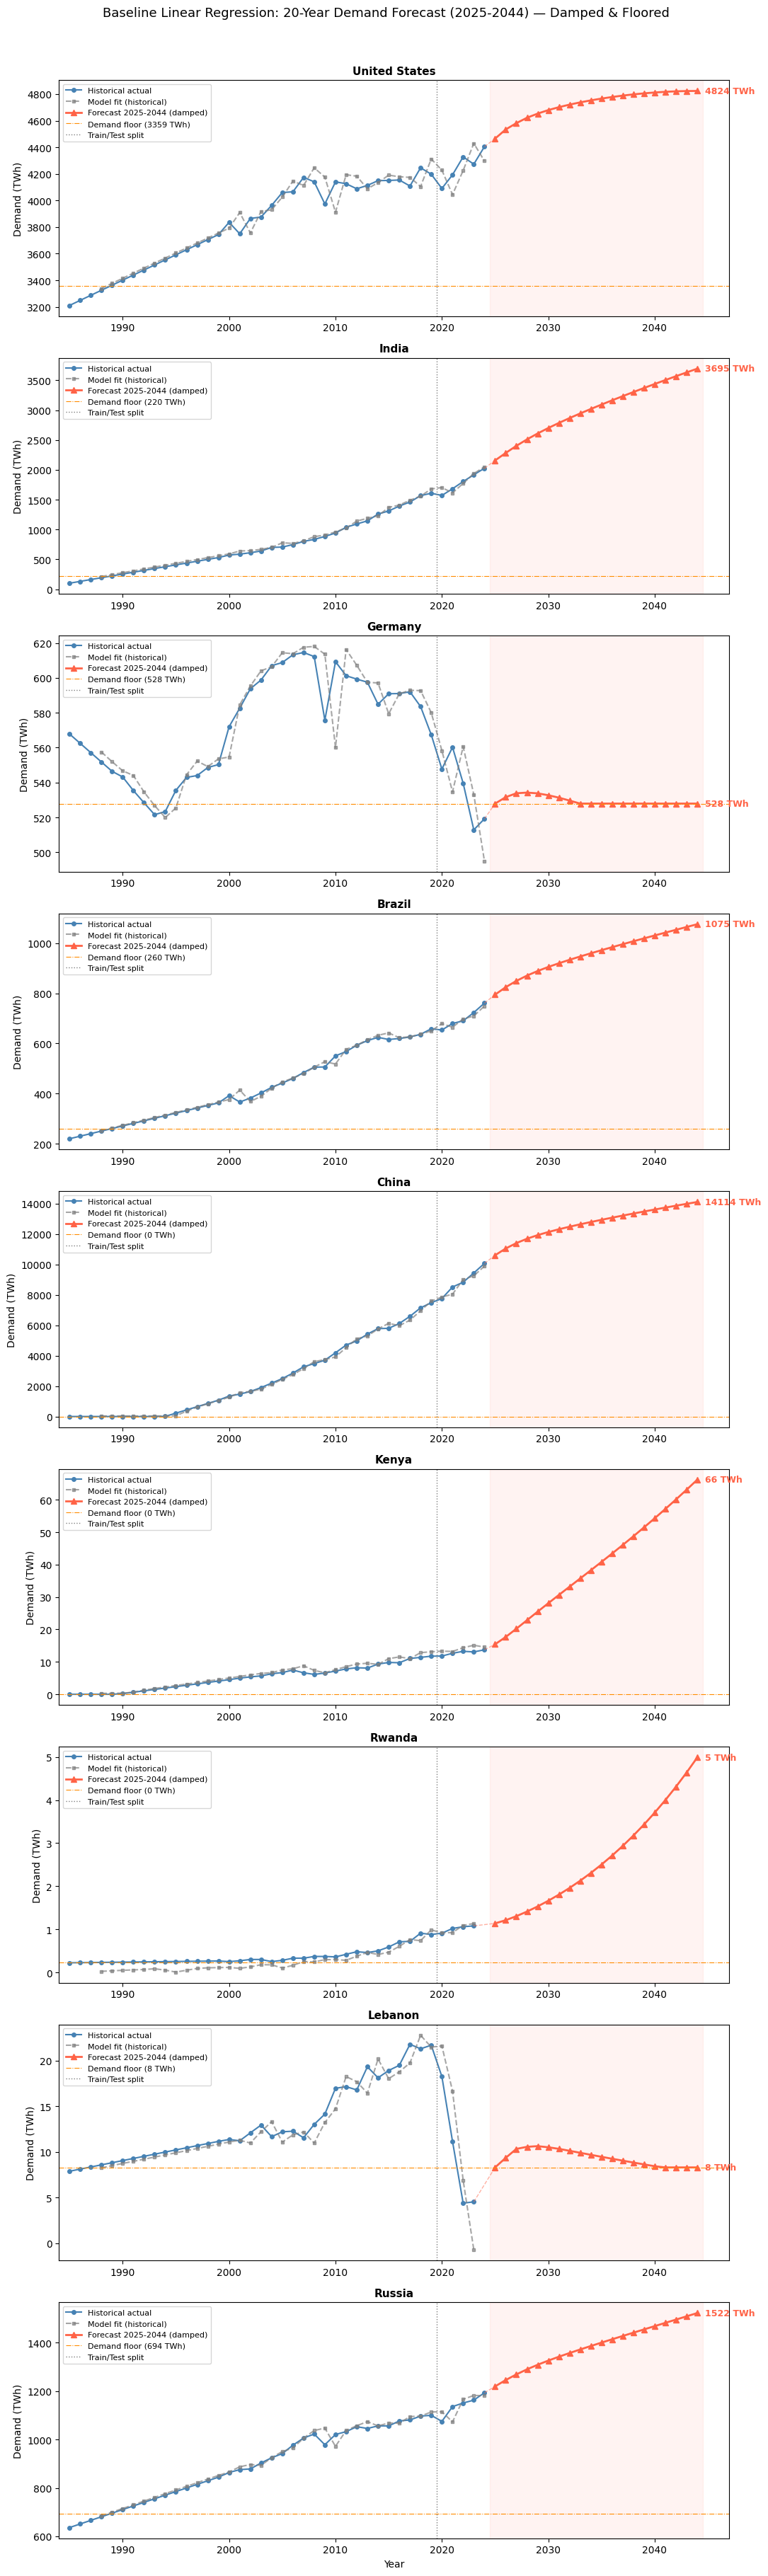

,Country,Year,Forecast (TWh)
0,United States,2025,4465.22
1,United States,2026,4533.99
2,United States,2027,4581.40
3,United States,2028,4621.94
4,United States,2029,4653.14
...,...,...,...
175,Russia,2040,1467.98
176,Russia,2041,1481.47
177,Russia,2042,1494.96
178,Russia,2043,1508.46


In [14]:
# ── 10-Year Future Forecast with Trend Damping & Floor Correction ─────────
#
# Problem: countries with a recent downward trend (e.g. Lebanon, Germany)
# will produce an ever-declining forecast because the autoregressive lag
# features keep compounding the negative momentum.
#
# Fix applied:
#   1. DAMPING      — the yoy_change signal decays toward 0 each step,
#                     so momentum fades rather than compounds.
#   2. FLOOR        — predictions are clipped to the country's historical
#                     minimum demand (physically, demand cannot go negative
#                     or drop far below the lowest ever recorded level).
#   3. REVERSION    — yoy_change is nudged slightly toward 0 each year,
#                     representing regression to a stable long-run state.

FORECAST_COUNTRIES = ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']
FORECAST_HORIZON   = 20           # years ahead (set to 10 if preferred)
LAST_DATA_YEAR     = int(df['year'].max())
EXOG_TREND_YEARS   = 5

# Damping parameters
DAMPING_FACTOR     = 0.80   # yoy_change is multiplied by this each step
#                             (0.80 = 20% decay per year; tune between 0.7-0.95)
FLOOR_PERCENTILE   = 10     # forecast floor = this percentile of historical demand
#                             (guards against going below plausible minimum)

def cagr_extrapolate(series, years_back, horizon):
    tail = series.dropna().iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        return [float(series.dropna().iloc[-1])] * horizon
    rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    last = float(tail.iloc[-1])
    return [last * (1 + rate) ** t for t in range(1, horizon + 1)]

forecast_records = {}
missing = []

for country in FORECAST_COUNTRIES:
    cdf = df[df['country'] == country].sort_values('year').copy()

    if cdf.empty or cdf[TARGET].dropna().empty:
        missing.append(country)
        continue

    known_demand = cdf[TARGET].dropna()

    # Historical floor: never forecast below this level
    hist_floor = float(np.percentile(known_demand.values, FLOOR_PERCENTILE))
    hist_floor = max(hist_floor, 0.0)   # hard zero floor (demand >= 0)

    # Seed lag values
    lag1 = float(known_demand.iloc[-1])
    lag2 = float(known_demand.iloc[-2]) if len(known_demand) >= 2 else lag1
    lag3 = float(known_demand.iloc[-3]) if len(known_demand) >= 3 else lag2
    yoy  = lag1 - lag2   # most recent year-over-year change

    # Extrapolate exogenous variables
    future_gdp = cagr_extrapolate(cdf['gdp'],        EXOG_TREND_YEARS, FORECAST_HORIZON)
    future_pop = cagr_extrapolate(cdf['population'], EXOG_TREND_YEARS, FORECAST_HORIZON)

    future_years  = list(range(LAST_DATA_YEAR + 1,
                                LAST_DATA_YEAR + FORECAST_HORIZON + 1))
    future_demand = []

    for t in range(FORECAST_HORIZON):
        gdp_pc = future_gdp[t] / future_pop[t] if future_pop[t] > 0 else 0

        X_step = pd.DataFrame([{
            'demand_lag1':       lag1,
            'demand_lag2':       lag2,
            'demand_lag3':       lag3,
            'demand_yoy_change': yoy,
            'gdp':               future_gdp[t],
            'population':        future_pop[t],
            'gdp_per_capita':    gdp_pc,
        }])

        pred = float(model.predict(X_step)[0])

        # ── Apply floor: clip to historical minimum ───────────────────────
        pred = max(pred, hist_floor)

        future_demand.append(pred)

        # ── Damp the momentum: decay yoy_change toward 0 ─────────────────
        raw_yoy = pred - lag1
        yoy     = raw_yoy * (DAMPING_FACTOR ** (t + 1))

        # Roll lags forward
        lag3 = lag2
        lag2 = lag1
        lag1 = pred

    forecast_records[country] = {
        'years':     future_years,
        'demand':    future_demand,
        'floor':     hist_floor,
    }

if missing:
    print(f"Warning - not found in dataset: {missing}")
print(f"Forecast ready for: {list(forecast_records.keys())}")
print(f"Damping factor: {DAMPING_FACTOR} | Floor percentile: {FLOOR_PERCENTILE}th")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(forecast_records), 1,
                          figsize=(11, 4 * len(forecast_records)), sharex=False)
if len(forecast_records) == 1:
    axes = [axes]

for ax, (country, fc) in zip(axes, forecast_records.items()):
    cdf_plot = df[df['country'] == country].sort_values('year')
    hist     = cdf_plot[['year', TARGET]].dropna()

    # Historical actual
    ax.plot(hist['year'], hist[TARGET], 'o-',
            color='steelblue', label='Historical actual', markersize=4, linewidth=1.5)

    # In-sample model fit
    cdf_model = df_model[df_model['country'] == country].copy()
    if not cdf_model.empty:
        cdf_model['fitted'] = model.predict(cdf_model[FEATURE_COLS])
        ax.plot(cdf_model['year'], cdf_model['fitted'], 's--',
                color='gray', label='Model fit (historical)', markersize=3, alpha=0.7)

    # Connect last historical point to first forecast point
    ax.plot([int(hist['year'].iloc[-1]), fc['years'][0]],
            [float(hist[TARGET].iloc[-1]), fc['demand'][0]],
            '--', color='tomato', linewidth=1, alpha=0.5)

    # Future forecast
    ax.plot(fc['years'], fc['demand'], '^-',
            color='tomato',
            label=f"Forecast {fc['years'][0]}-{fc['years'][-1]} (damped)",
            markersize=6, linewidth=2)

    # Floor reference line
    ax.axhline(fc['floor'], color='darkorange', linestyle='-.', linewidth=0.8,
               label=f"Demand floor ({fc['floor']:.0f} TWh)")

    # Shaded forecast region
    ax.axvspan(fc['years'][0] - 0.5, fc['years'][-1] + 0.5,
               alpha=0.07, color='tomato')

    # Train/test split
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1,
               label='Train/Test split')

    # Annotate final forecast value
    ax.annotate(
        f"{fc['demand'][-1]:.0f} TWh",
        xy=(fc['years'][-1], fc['demand'][-1]),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, color='tomato', va='center', fontweight='bold'
    )

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(int(hist['year'].min()) - 1, fc['years'][-1] + 3)

axes[-1].set_xlabel('Year')
fig.suptitle(
    f"Baseline Linear Regression: {FORECAST_HORIZON}-Year Demand Forecast "
    f"({LAST_DATA_YEAR+1}-{LAST_DATA_YEAR+FORECAST_HORIZON}) — Damped & Floored",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
summary_rows = []
for country, fc in forecast_records.items():
    for yr, demand in zip(fc['years'], fc['demand']):
        summary_rows.append({
            'Country': country,
            'Year': yr,
            'Forecast (TWh)': round(demand, 2)
        })

forecast_table = pd.DataFrame(summary_rows)
forecast_table
